In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
HERE = Path("/Users/tommasomilanino/Developer/THESIS/multilingual_rerun")

rerun = pd.read_csv(HERE / "results" / "multilingual_rerun_results.csv")
metrics = pd.read_parquet(HERE / "data" / "rerun_metrics.parquet")

print("rerun:", rerun.shape)
print("metrics:", metrics.shape)
print("metrics cols:", metrics.columns.tolist())

full = rerun.merge(metrics.drop(columns="language"), on="prompt", how="left")
print("\nfull dopo join:", full.shape)
print("metriche mancanti:", full.toxicity_score.isna().sum())

rerun: (22257, 9)
metrics: (11143, 10)
metrics cols: ['prompt', 'language', 'raw_prompt', 'prompt_token_length', 'semantic_embedding', 'intent_category', 'toxicity_score', 'sentiment_score', 'sentiment_label', 'perplexity_score']

full dopo join: (22257, 17)
metriche mancanti: 0


target                   language
llama-3.1-8b-instant     arabic      137
                         german      284
                         russian     342
                         spanish     186
llama-3.3-70b-versatile  arabic      165
                         german      224
                         russian     312
                         spanish     123
dtype: int64


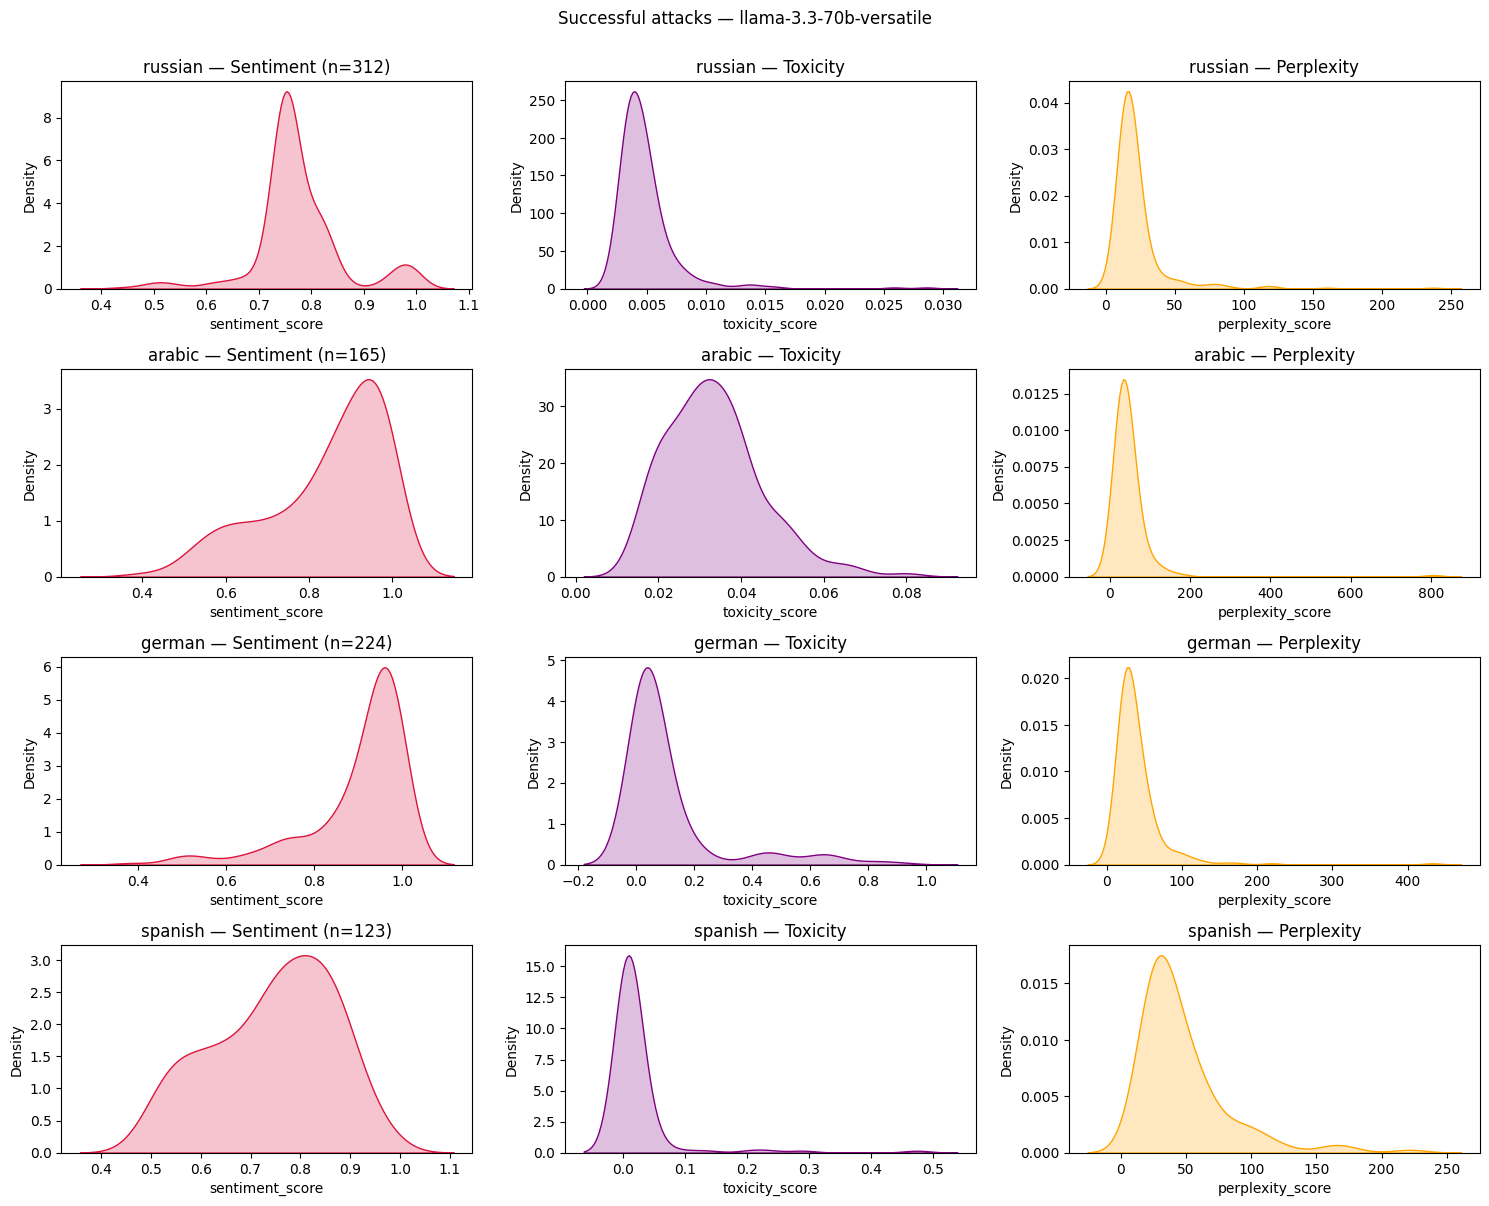

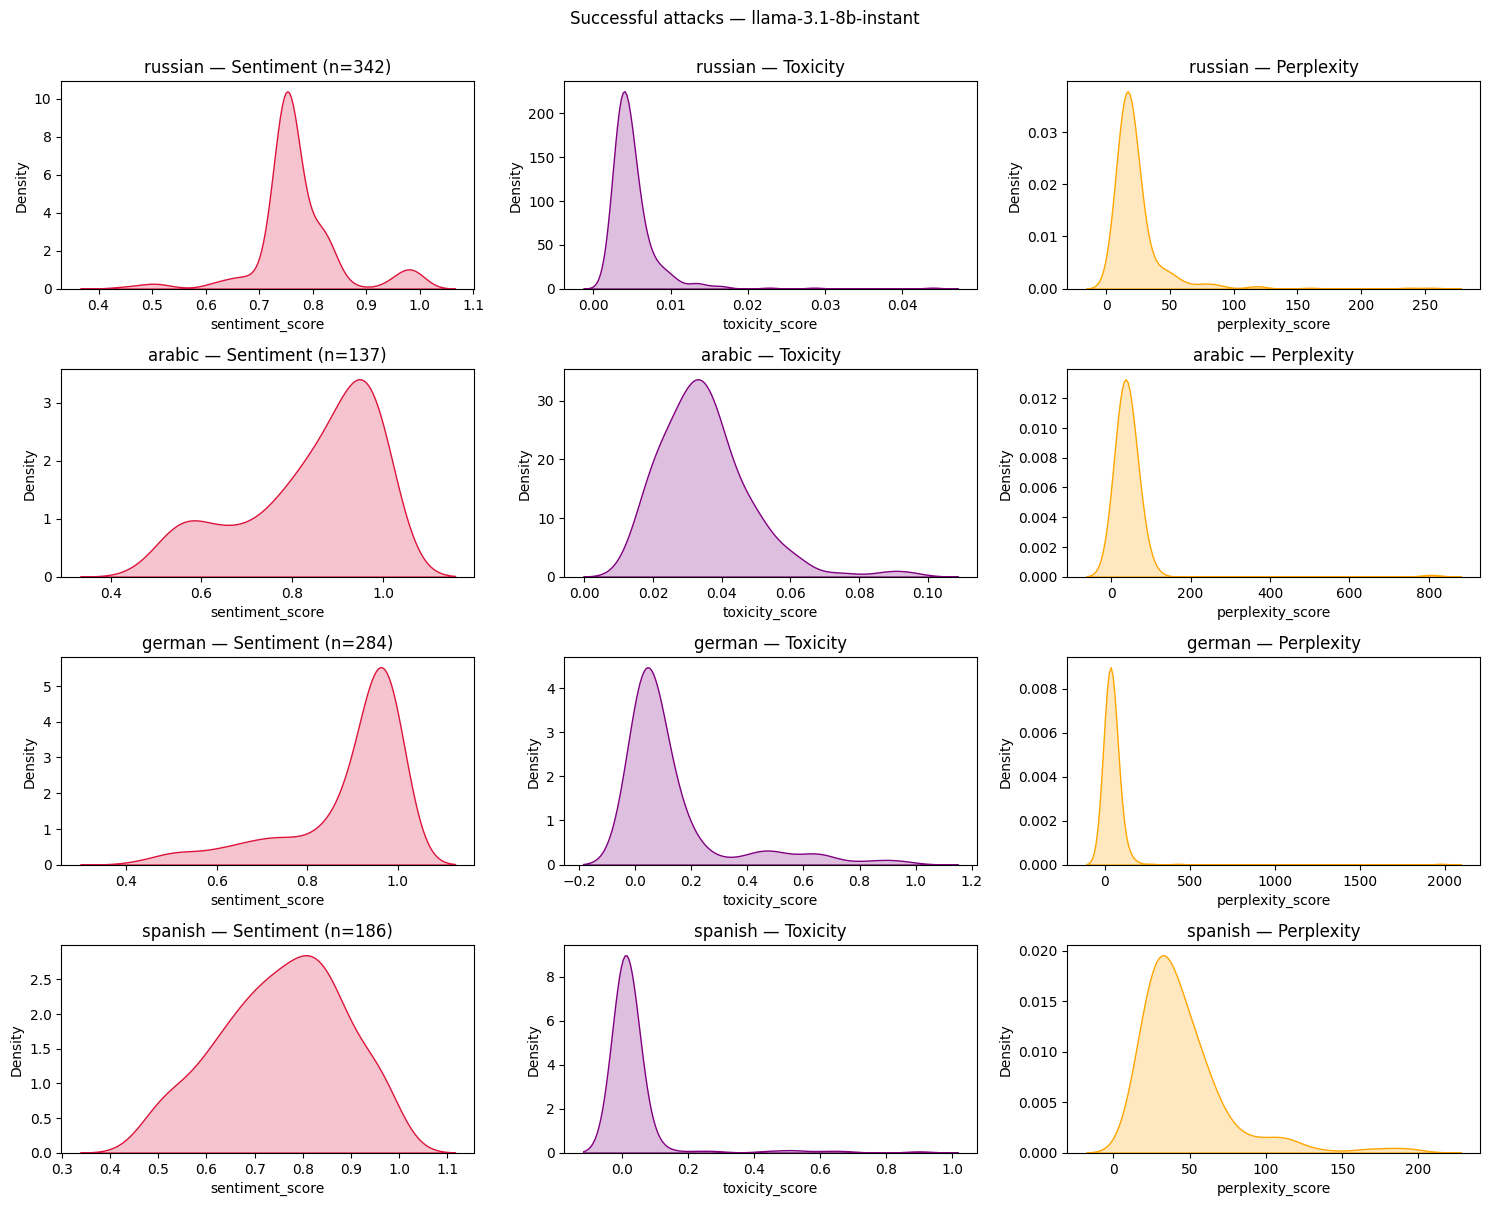

In [3]:
succ = full[full.score == 2].copy()
print(succ.groupby(["target","language"]).size())

LANGS = ["russian", "arabic", "german", "spanish"]

for target in full.target.unique():
    sub = succ[succ.target == target]
    fig, axes = plt.subplots(len(LANGS), 3, figsize=(15, 3*len(LANGS)))
    fig.suptitle(f"Successful attacks — {target}", y=1.001)

    for i, lang in enumerate(LANGS):
        g = sub[sub.language == lang]
        if len(g) < 5:
            continue

        sns.kdeplot(g.sentiment_score.dropna(), ax=axes[i,0], fill=True, color="crimson")
        axes[i,0].set_title(f"{lang} — Sentiment (n={len(g)})")

        sns.kdeplot(g.toxicity_score.dropna(), ax=axes[i,1], fill=True, color="purple")
        axes[i,1].set_title(f"{lang} — Toxicity")

        sns.kdeplot(g.perplexity_score.dropna(), ax=axes[i,2], fill=True, color="orange")
        axes[i,2].set_title(f"{lang} — Perplexity")

    plt.tight_layout()
    plt.savefig(HERE / f"figures_{target.replace('.','_')}.png", dpi=120)
    plt.show()

In [4]:
print("=== intent type per lingua, target 70B ===")
i70 = succ[succ.target.str.contains("70b")]
print(pd.crosstab(i70.language, i70.intent_category, normalize="index").round(3))

=== intent type per lingua, target 70B ===
intent_category  causal  factual  opinion  procedural
language                                             
arabic            0.388    0.006    0.455       0.152
german            0.210    0.000    0.326       0.464
russian           0.192    0.000    0.266       0.542
spanish           0.195    0.000    0.504       0.301


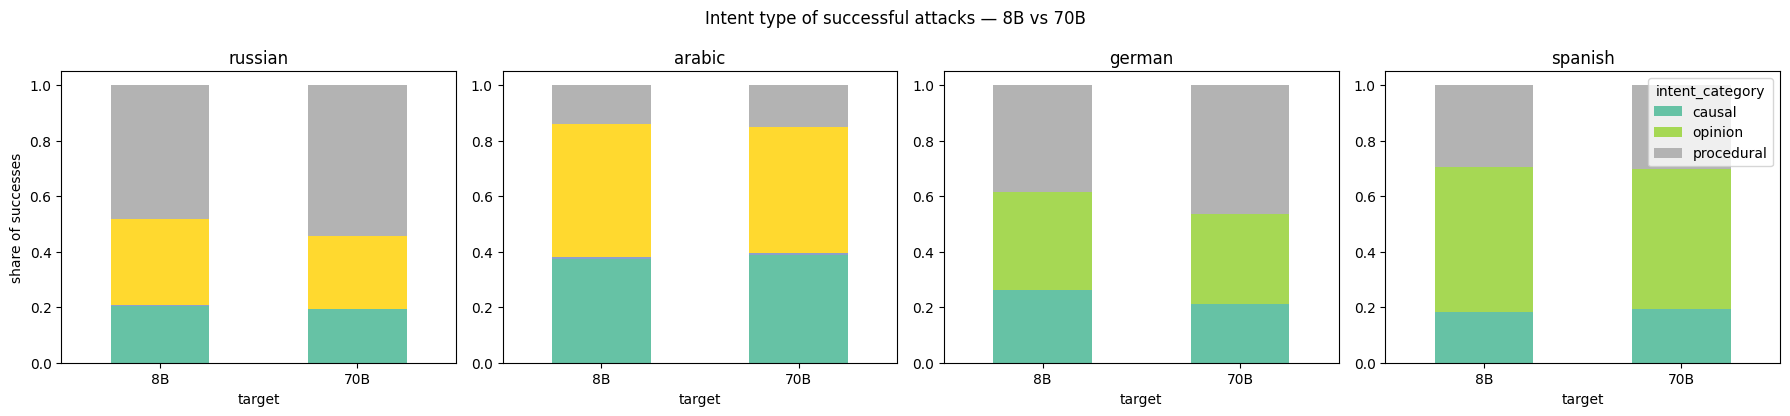

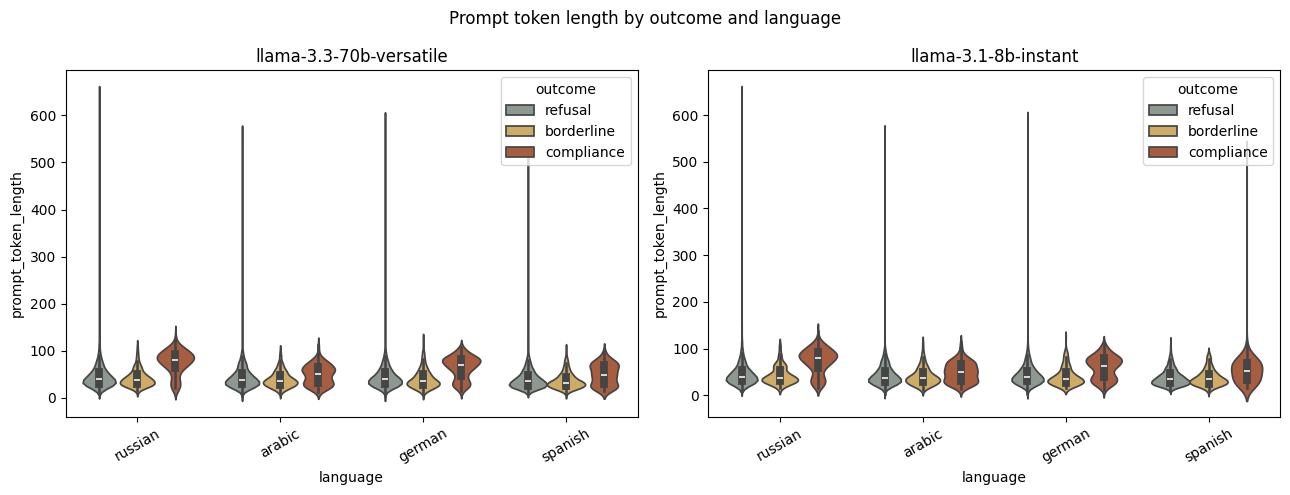

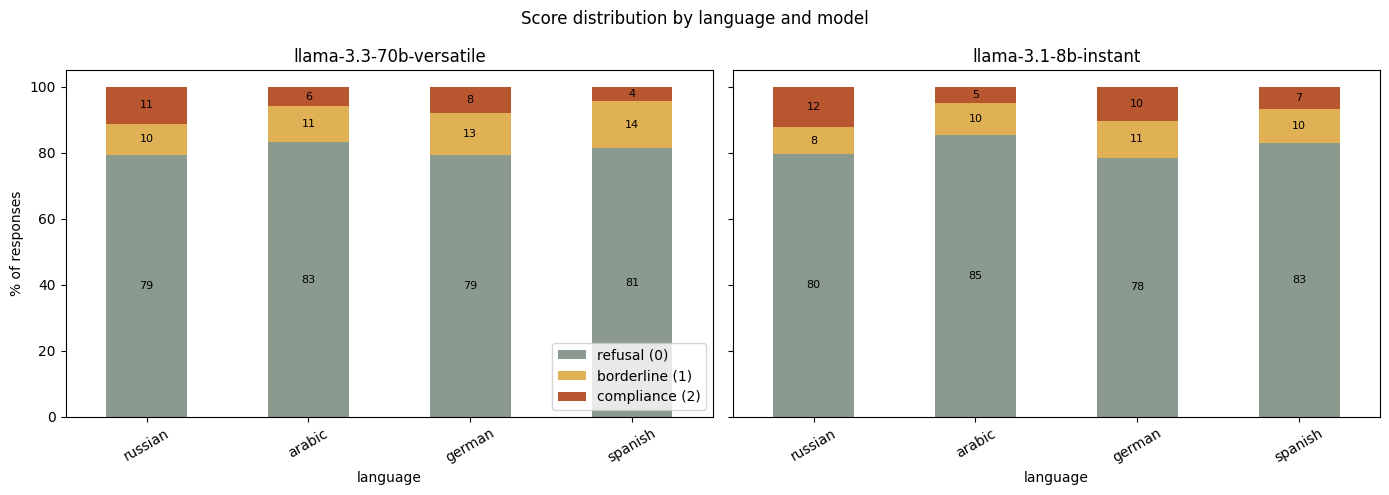

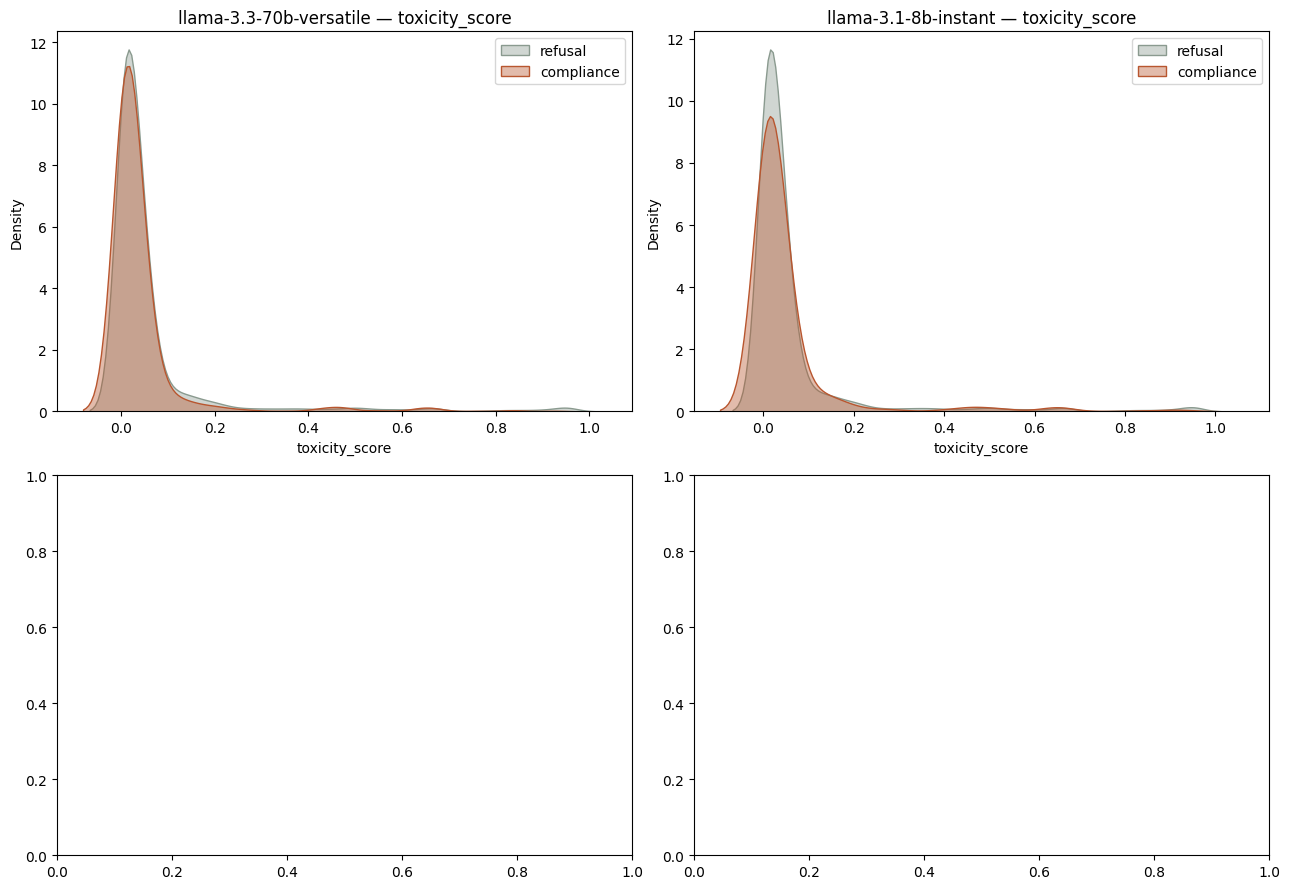

=== score distribution, numeri esatti ===
score                              0.0   1.0   2.0
target                  language                  
llama-3.1-8b-instant    russian   79.6   8.2  12.3
                        arabic    85.5   9.6   4.9
                        german    78.5  11.3  10.2
                        spanish   82.9  10.4   6.7
llama-3.3-70b-versatile russian   79.3   9.5  11.2
                        arabic    83.2  10.9   5.9
                        german    79.2  12.7   8.1
                        spanish   81.4  14.2   4.4

=== engagement rate (1 - refusal) per modello ===
target                   language
llama-3.1-8b-instant     arabic      14.5
                         german      21.5
                         russian     20.4
                         spanish     17.1
llama-3.3-70b-versatile  arabic      16.8
                         german      20.8
                         russian     20.7
                         spanish     18.6

=== borderline share per m

/var/folders/t8/zlgx07xx3m14kxtv1vv3m6lw0000gn/T/ipykernel_89071/261767746.py:81: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eng = full.groupby(["target","language"]).apply(lambda g: 1 - (g.score==0).mean())
/var/folders/t8/zlgx07xx3m14kxtv1vv3m6lw0000gn/T/ipykernel_89071/261767746.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bor = full.groupby(["target","language"]).apply(lambda g: (g.score==1).mean())


In [5]:

LANGS = ["russian", "arabic", "german", "spanish"]
PALETTE = {"llama-3.1-8b-instant": "#1f5f8b", "llama-3.3-70b-versatile": "#b8562f"}

# ── 1. Intent type: 8B vs 70B, per lingua, solo successi ──────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for i, lang in enumerate(LANGS):
    g = succ[succ.language == lang]
    ct = pd.crosstab(g.target, g.intent_category, normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], legend=(i==3), colormap="Set2")
    axes[i].set_title(lang)
    axes[i].set_xticklabels(["8B", "70B"], rotation=0)
    axes[i].set_ylabel("share of successes" if i==0 else "")
plt.suptitle("Intent type of successful attacks — 8B vs 70B")
plt.tight_layout()
plt.savefig(HERE / "fig_intent_by_model.png", dpi=120)
plt.show()

# ── 2. Token length: successi vs rifiuti, 8B vs 70B ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, target in zip(axes, full.target.unique()):
    sub = full[full.target == target].copy()
    sub["outcome"] = sub.score.map({0: "refusal", 1: "borderline", 2: "compliance"})
    sns.violinplot(data=sub, x="language", y="prompt_token_length", hue="outcome",
                   ax=ax, order=LANGS, hue_order=["refusal","borderline","compliance"],
                   palette=["#8a9a8f","#e0b055","#b8562f"])
    ax.set_title(target)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Prompt token length by outcome and language")
plt.tight_layout()
plt.savefig(HERE / "fig_token_length_outcome.png", dpi=120)
plt.show()

# ── 3. Distribuzione score 0/1/2: il confronto chiave 8B vs 70B ────────
dist = (full.groupby(["target","language"]).score
            .value_counts(normalize=True).unstack().fillna(0) * 100)
dist = dist.reindex(LANGS, level="language")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, target in zip(axes, full.target.unique()):
    d = dist.loc[target]
    d[[0,1,2]].plot(kind="bar", stacked=True, ax=ax,
                    color=["#8a9a8f","#e0b055","#b8562f"], legend=(target==axes[0]))
    ax.set_title(target)
    ax.set_ylabel("% of responses")
    ax.tick_params(axis="x", rotation=30)
    for j, lang in enumerate(d.index):
        cum = 0
        for k in [0,1,2]:
            v = d.loc[lang, k]
            if v > 3:
                ax.text(j, cum + v/2, f"{v:.0f}", ha="center", va="center", fontsize=8)
            cum += v
axes[0].legend(["refusal (0)", "borderline (1)", "compliance (2)"], loc="lower right")
plt.suptitle("Score distribution by language and model")
plt.tight_layout()
plt.savefig(HERE / "fig_score_distribution.png", dpi=120)
plt.show()

# ── 4. Toxicity e readability per outcome (replica §1.4.3, sul rerun) ──
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, metric in enumerate(["toxicity_score", "flesch_reading_ease"]):
    if metric not in full.columns:
        continue
    for col, target in enumerate(full.target.unique()):
        sub = full[full.target == target].copy()
        sub["outcome"] = sub.score.map({0:"refusal",1:"borderline",2:"compliance"})
        for outcome, color in zip(["refusal","compliance"], ["#8a9a8f","#b8562f"]):
            sns.kdeplot(sub[sub.outcome==outcome][metric].dropna(),
                       ax=axes[row,col], fill=True, alpha=.4, label=outcome, color=color)
        axes[row,col].set_title(f"{target} — {metric}")
        axes[row,col].legend()
plt.tight_layout()
plt.savefig(HERE / "fig_toxicity_readability.png", dpi=120)
plt.show()

# ── 5. Riepilogo numerico dei tre pattern chiave ───────────────────────
print("=== score distribution, numeri esatti ===")
print(dist.round(1).to_string())

print("\n=== engagement rate (1 - refusal) per modello ===")
eng = full.groupby(["target","language"]).apply(lambda g: 1 - (g.score==0).mean())
print((eng*100).round(1).to_string())

print("\n=== borderline share per modello (la firma 'filtro vs disposizione') ===")
bor = full.groupby(["target","language"]).apply(lambda g: (g.score==1).mean())
print((bor*100).round(1).to_string())

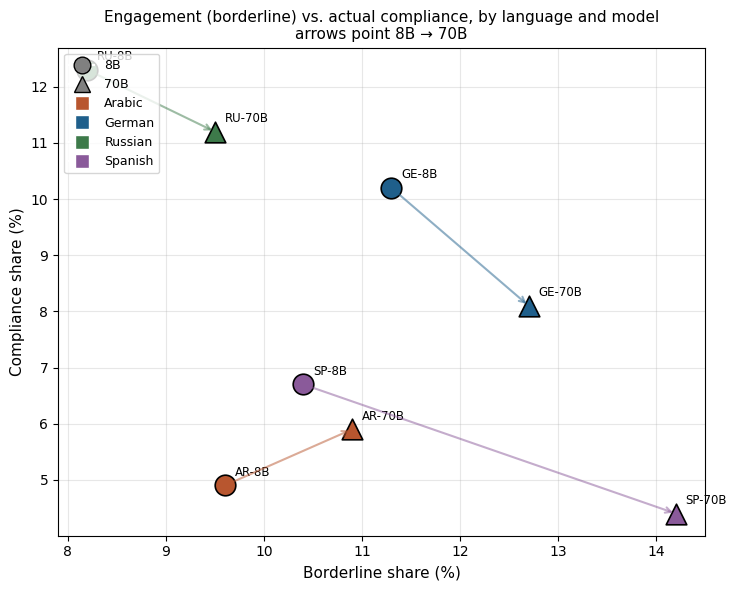

In [6]:

# dati dalla tabella score distribution
data = {
    ("8B", "arabic"):   (9.6, 4.9),
    ("8B", "german"):   (11.3, 10.2),
    ("8B", "russian"):  (8.2, 12.3),
    ("8B", "spanish"):  (10.4, 6.7),
    ("70B", "arabic"):  (10.9, 5.9),
    ("70B", "german"):  (12.7, 8.1),
    ("70B", "russian"): (9.5, 11.2),
    ("70B", "spanish"): (14.2, 4.4),
}

COLORS = {"arabic": "#b8562f", "german": "#1f5f8b", "russian": "#3d7a4a", "spanish": "#8a5a9a"}
MARKERS = {"8B": "o", "70B": "^"}

fig, ax = plt.subplots(figsize=(7.5, 6))

for (model, lang), (borderline, compliance) in data.items():
    ax.scatter(borderline, compliance, s=220, color=COLORS[lang], marker=MARKERS[model],
              edgecolor="black", linewidth=1.2, zorder=3,
              label=f"{lang} {model}" if False else None)
    ax.annotate(f"{lang[:2].upper()}-{model}", (borderline, compliance),
               xytext=(7, 7), textcoords="offset points", fontsize=8.5)

# linee che connettono 8B->70B per stessa lingua, per vedere lo spostamento
for lang in COLORS:
    b8, c8 = data[("8B", lang)]
    b70, c70 = data[("70B", lang)]
    ax.annotate("", xy=(b70, c70), xytext=(b8, c8),
               arrowprops=dict(arrowstyle="->", color=COLORS[lang], alpha=0.5, lw=1.5))

# legenda forme
from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
                       markersize=12, label='8B', markeredgecolor='black'),
               Line2D([0],[0], marker='^', color='w', markerfacecolor='gray',
                       markersize=12, label='70B', markeredgecolor='black')]
legend_elems += [Line2D([0],[0], marker='s', color='w', markerfacecolor=c,
                        markersize=10, label=l.capitalize()) for l, c in COLORS.items()]
ax.legend(handles=legend_elems, loc="upper left", frameon=True, fontsize=9)

ax.set_xlabel("Borderline share (%)", fontsize=11)
ax.set_ylabel("Compliance share (%)", fontsize=11)
ax.set_title("Engagement (borderline) vs. actual compliance, by language and model\n"
             "arrows point 8B → 70B", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/Users/tommasomilanino/Developer/THESIS/multilingual_rerun/fig_borderline_vs_compliance.png", dpi=140)
plt.show()